## Lab 6: Fashion-MNIST Decision Trees

This notebook implements the lab tasks for exploring decision trees on the Fashion-MNIST dataset:

1. Load and explore the dataset
2. Create a train–test split
3. Train decision trees with different depths and analyze overfitting/underfitting
4. Summarize observations about model complexity and generalization.


In [1]:
# Task 1: Load and Explore Fashion-MNIST

from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set()

# Load Fashion-MNIST (may take a few minutes on first run)
X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Data type of X:", X.dtype)
print("Unique labels in y (first 10 shown):", np.unique(y)[:10])


X shape: (70000, 784)
y shape: (70000,)
Data type of X: int64
Unique labels in y (first 10 shown): ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


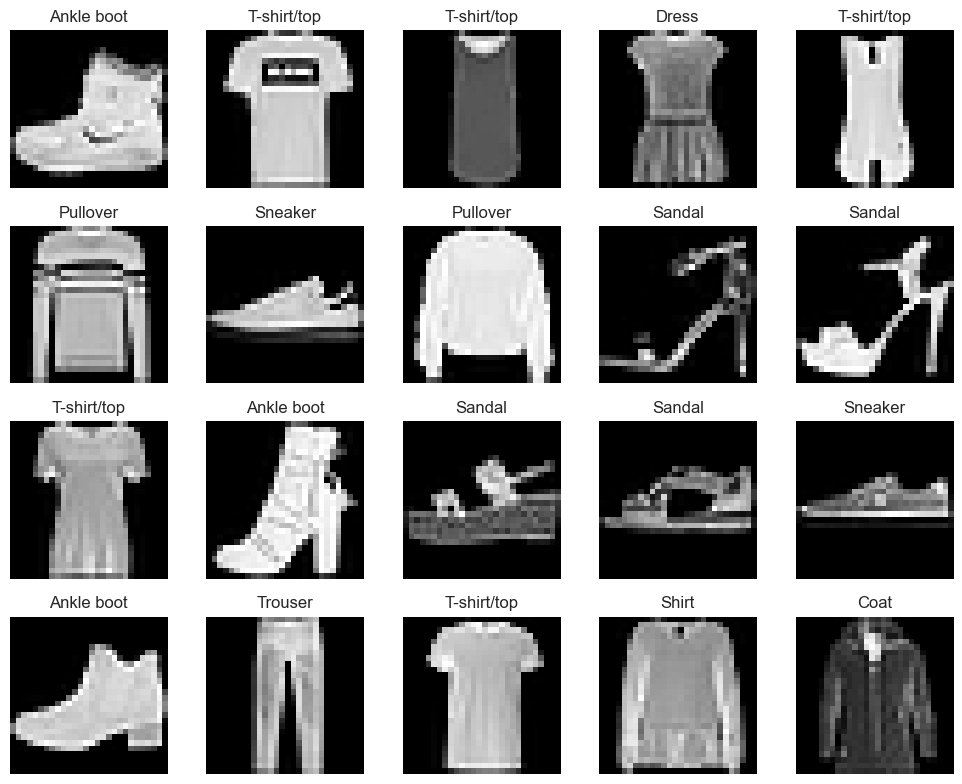

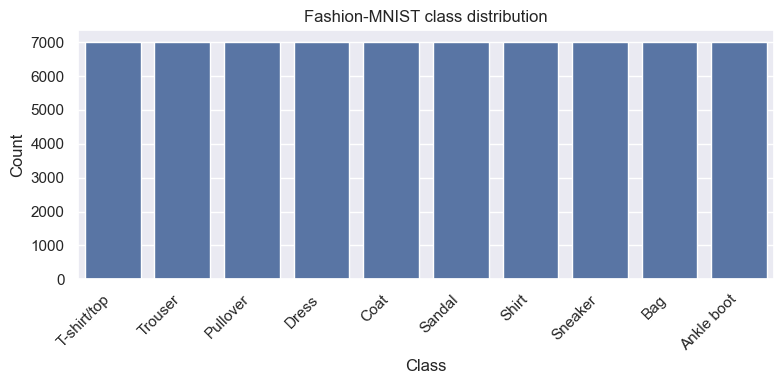

Class counts:
 0    7000
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
9    7000
Name: count, dtype: int64

Pixel stats for sample 0 (label = Ankle boot)
Mean: 97.25382653061224
Std: 101.79234620324726
Min: 0
Max: 255


In [2]:
# Task 1.2: Visualization, class distribution, and basic stats

# Label names from Fashion-MNIST documentation
label_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

# Convert labels to integers
y_int = y.astype(int)

# (a) Show 20 sample images
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
axes = axes.ravel()

for i in range(20):
    ax = axes[i]
    img = X[i].reshape(28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(label_names[int(y_int[i])])
    ax.axis("off")

plt.tight_layout()
plt.show()

# (b) Class distribution
class_counts = pd.Series(y_int).value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks(class_counts.index, [label_names[i] for i in class_counts.index], rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Fashion-MNIST class distribution")
plt.tight_layout()
plt.show()

print("Class counts:\n", class_counts)

# (c) Basic statistics for a single sample
sample_idx = 0
sample = X[sample_idx]
print(f"\nPixel stats for sample {sample_idx} (label = {label_names[int(y_int[sample_idx])]})")
print("Mean:", sample.mean())
print("Std:", sample.std())
print("Min:", sample.min())
print("Max:", sample.max())


In [3]:
# Task 2: Train–Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_int, test_size=1/7, random_state=42, stratify=y_int
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (60000, 784)
X_test shape: (10000, 784)
y_train shape: (60000,)
y_test shape: (10000,)


In [4]:
# Task 3.1 & 3.3: Train Decision Trees with varying depths

from sklearn.tree import DecisionTreeClassifier, plot_tree
import time

max_depth_list = [2, 5, 10, 20, None]
results = []

for depth in max_depth_list:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    start_time = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - start_time

    train_acc = clf.score(X_train, y_train)
    test_acc = clf.score(X_test, y_test)
    n_nodes = clf.tree_.node_count

    results.append({
        "max_depth": depth if depth is not None else "None",
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "n_nodes": n_nodes,
        "train_time_sec": train_time,
    })

results_df = pd.DataFrame(results)
results_df


,max_depth,train_accuracy,test_accuracy,n_nodes,train_time_sec
0,2,0.356633,0.3548,7,7.779448
1,5,0.710333,0.7014,63,18.758010
2,10,0.845667,0.8115,1179,34.169802
3,20,0.985217,0.8060,8123,54.199265
4,None,1.000000,0.7969,9981,69.066396


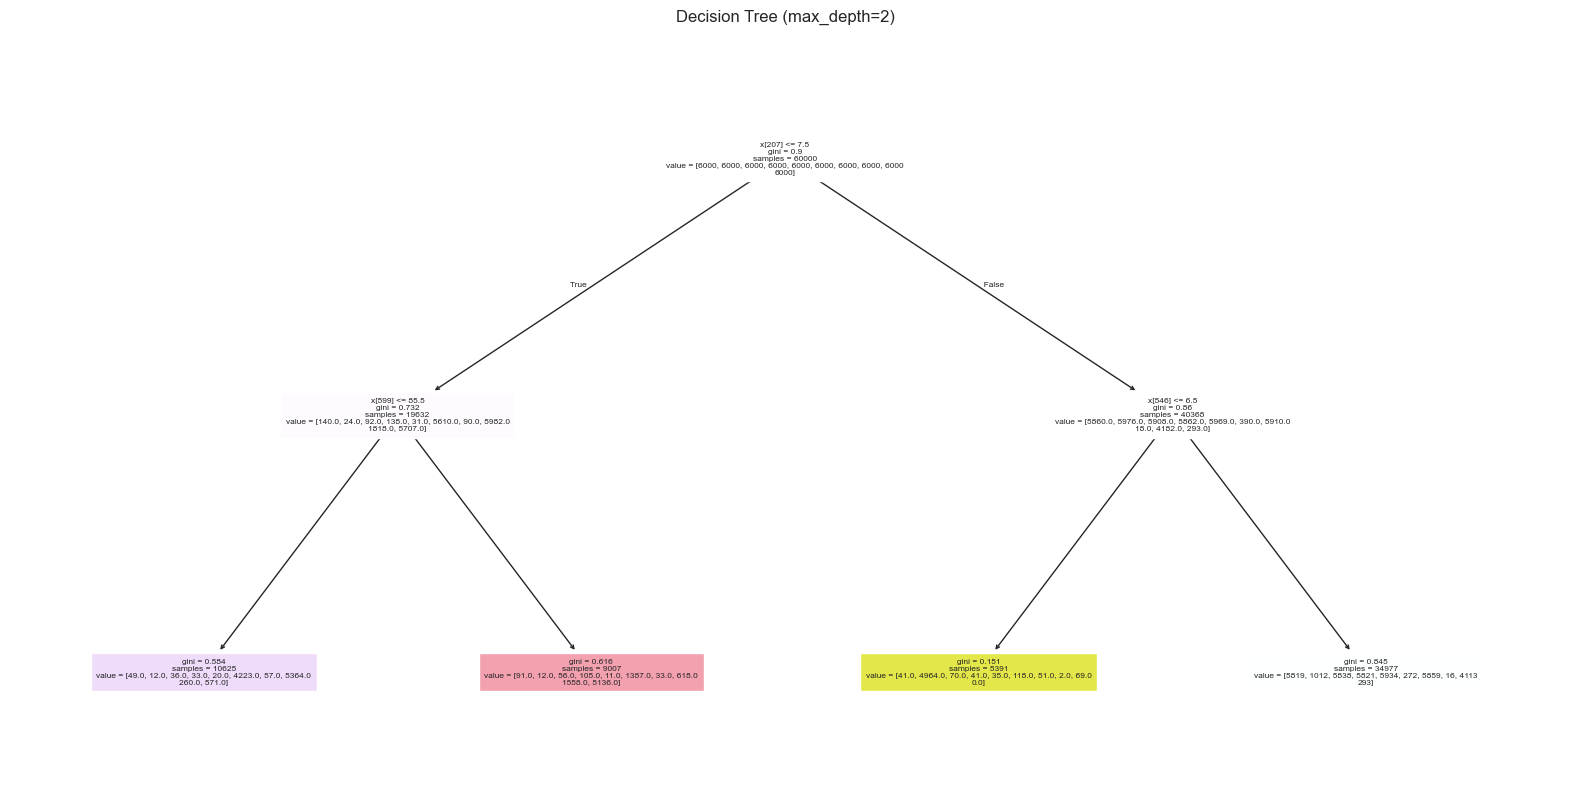

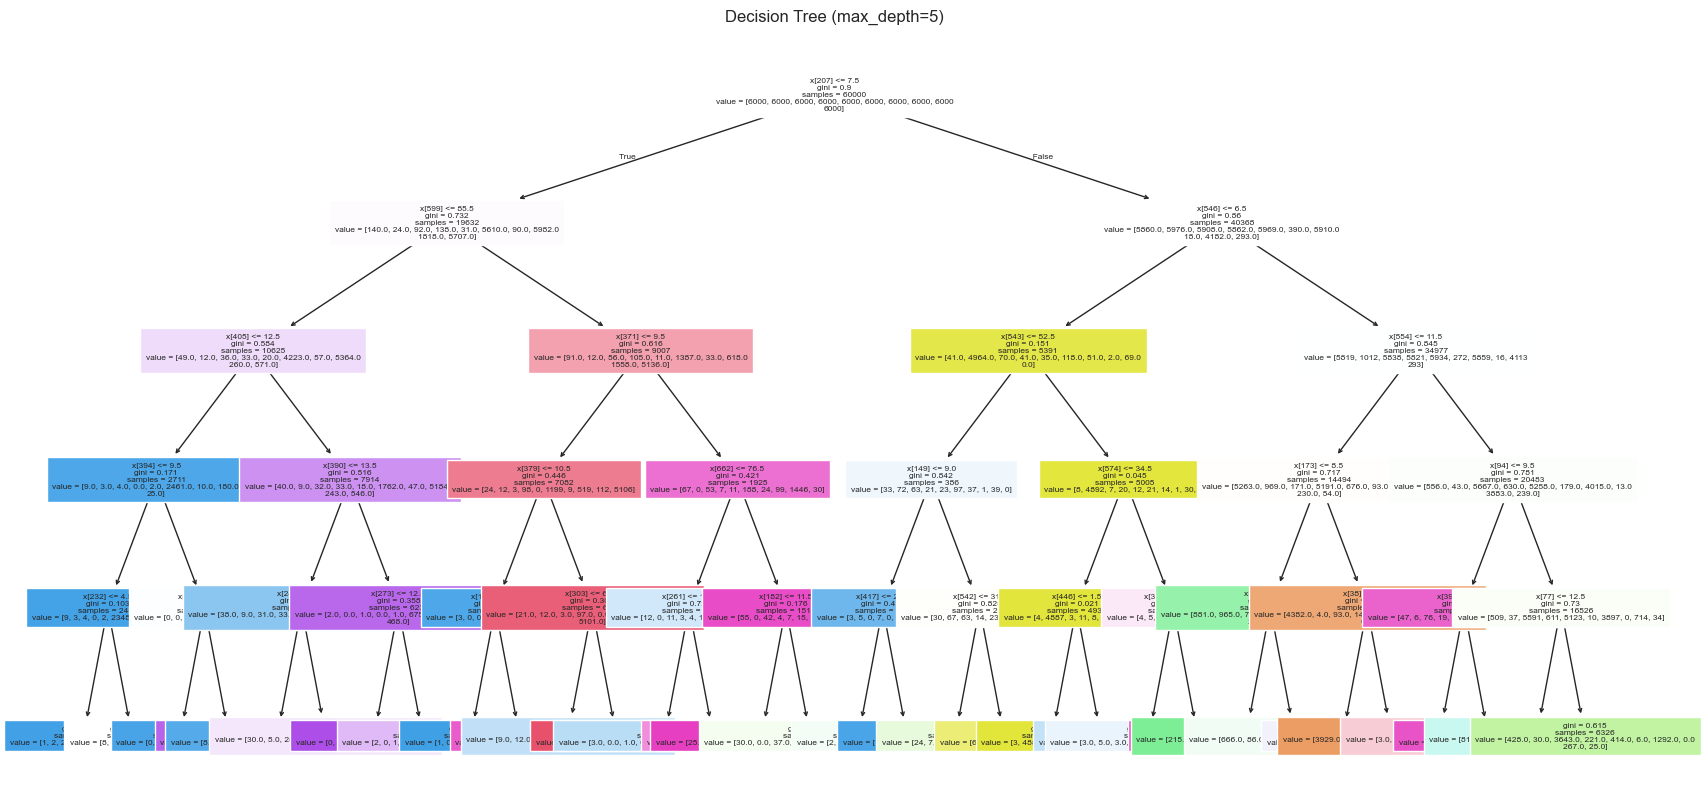

In [5]:
# Task 3.2: Visualize small trees (max_depth <= 5)

small_depths = [2, 5]

for depth in small_depths:
    clf_small = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf_small.fit(X_train, y_train)

    plt.figure(figsize=(20, 10))
    plot_tree(
        clf_small,
        max_depth=depth,
        filled=True,
        fontsize=6,
    )
    plt.title(f"Decision Tree (max_depth={depth})")
    plt.show()


## Task 3 (Extra): Hyperparameter Tuning with Grid Search

Here we use `GridSearchCV` to search over multiple decision tree hyperparameters (e.g., `max_depth`, `min_samples_split`, `min_samples_leaf`) and compare the best model to the manually chosen depths.


In [6]:
# Grid search over decision tree hyperparameters

from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [2, 5, 10, 20, None],
    "min_samples_split": [2, 10, 50],
    "min_samples_leaf": [1, 5, 10],
}

base_clf = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated accuracy:", grid_search.best_score_)

best_clf = grid_search.best_estimator_
print("Train accuracy (best model):", best_clf.score(X_train, y_train))
print("Test accuracy (best model):", best_clf.score(X_test, y_test))


Fitting 3 folds for each of 45 candidates, totalling 135 fits


KeyboardInterrupt: 